Dataset Shape: (187, 15)


,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263.0,1269.0,25198.0,9796.0,106.0,10.0,18.0,3.50,69.49,5.04,35526.0,737.0,2.07,Eastern Mediterranean
1,Albania,4880.0,144.0,2745.0,1991.0,117.0,6.0,63.0,2.95,56.25,5.25,4171.0,709.0,17.00,Europe
2,Algeria,27973.0,1163.0,18837.0,7973.0,616.0,8.0,749.0,4.16,67.34,NaN,23691.0,4282.0,18.07,Africa
3,Andorra,907.0,52.0,803.0,52.0,10.0,0.0,0.0,5.73,88.53,6.48,884.0,NaN,2.60,Europe
4,Angola,950.0,41.0,242.0,667.0,18.0,1.0,0.0,4.32,25.47,16.94,749.0,201.0,26.84,Africa



Detected Columns:
Country/Region Country/Region Confirmed Deaths Confirmed last week

Missing Values:


,Column,Missing Values
10,Deaths / 100 Recovered,14
0,Country/Region,9
1,Confirmed,9
2,Deaths,9
3,Recovered,9
4,Active,9
5,New cases,9
6,New deaths,9
7,New recovered,9
8,Deaths / 100 Cases,9



Cleaned data saved

--- UNIT 1 ---

Summary Statistics by Region:


,Country/Region,Confirmed_mean,Confirmed_median,Confirmed_std,Confirmed_min,Confirmed_max,Deaths_mean,Deaths_median,Deaths_std,Deaths_min,Deaths_max
0,Afghanistan,36263.0,36263.0,NaN,36263.0,36263.0,1269.0,1269.0,NaN,1269.0,1269.0
1,Albania,4880.0,4880.0,NaN,4880.0,4880.0,144.0,144.0,NaN,144.0,144.0
2,Algeria,27973.0,27973.0,NaN,27973.0,27973.0,1163.0,1163.0,NaN,1163.0,1163.0
3,Andorra,907.0,907.0,NaN,907.0,907.0,52.0,52.0,NaN,52.0,52.0
4,Angola,950.0,950.0,NaN,950.0,950.0,41.0,41.0,NaN,41.0,41.0
...,...,...,...,...,...,...,...,...,...,...,...
173,West Bank and Gaza,10621.0,10621.0,NaN,10621.0,10621.0,78.0,78.0,NaN,78.0,78.0
174,Western Sahara,10.0,10.0,NaN,10.0,10.0,1.0,1.0,NaN,1.0,1.0
175,Yemen,1691.0,1691.0,NaN,1691.0,1691.0,483.0,483.0,NaN,483.0,483.0
176,Zambia,4552.0,4552.0,NaN,4552.0,4552.0,140.0,140.0,NaN,140.0,140.0


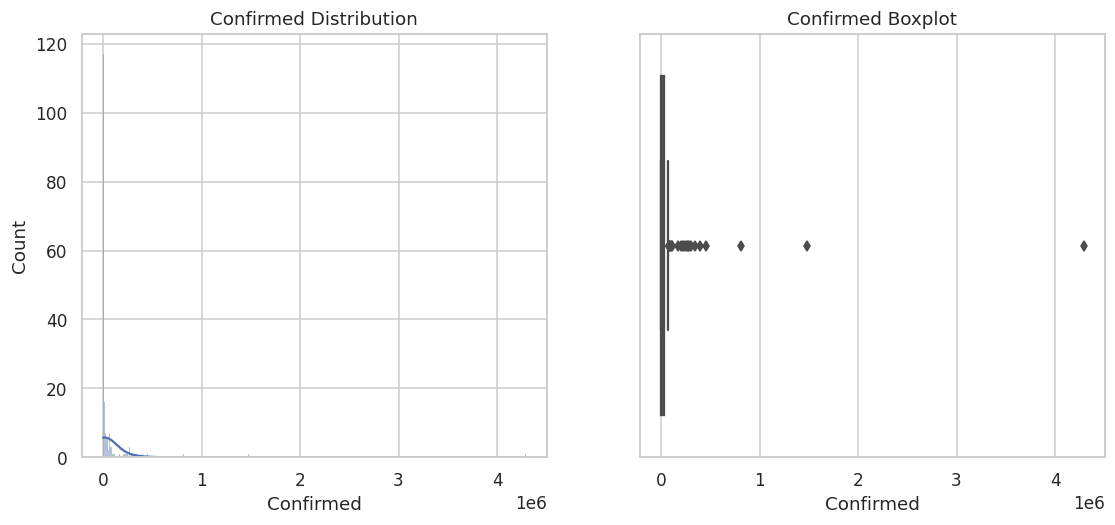

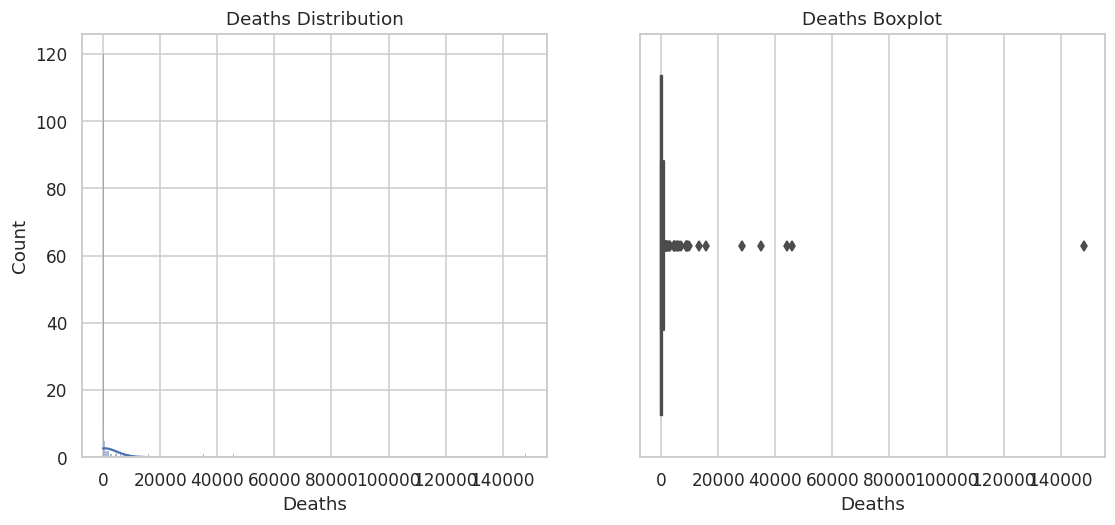

Confirmed: Right-skewed (skew=10.65)
Outliers in Confirmed: 26 (Bounds: -42869.75, 74992.25)
Deaths: Right-skewed (skew=9.61)
Outliers in Deaths: 34 (Bounds: -717.00, 1247.00)


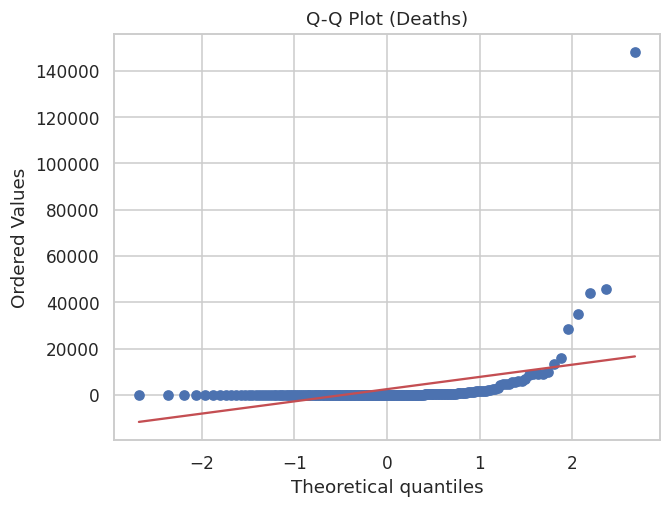

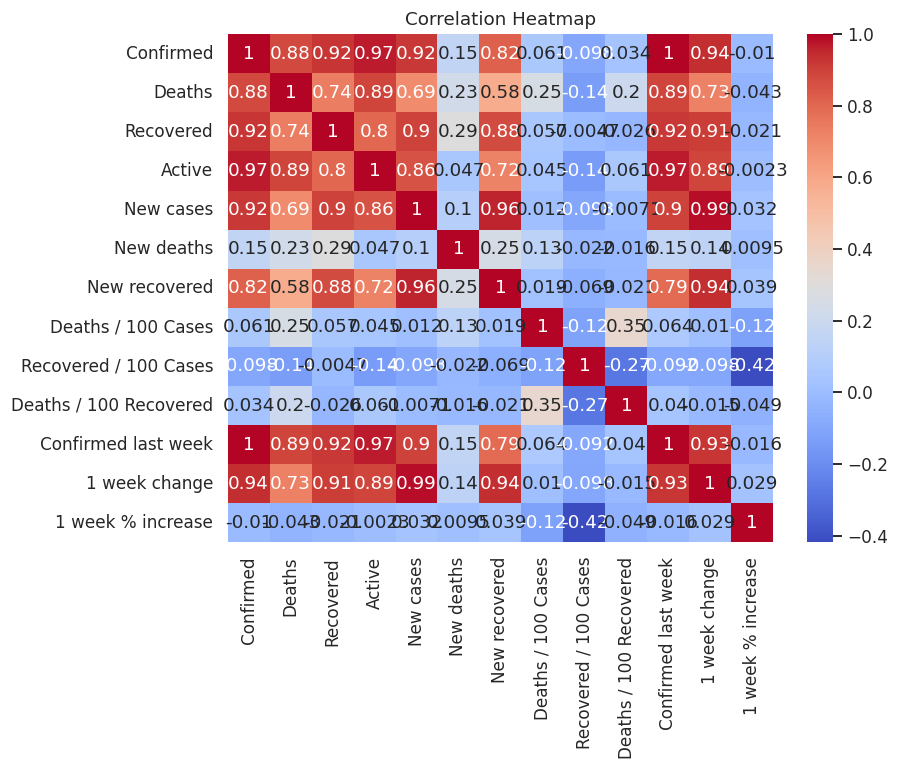


Top Correlations with Deaths:


,Feature,Correlation
0,Deaths,1.000
1,Active,0.894
2,Confirmed last week,0.893
3,Confirmed,0.881
4,Recovered,0.736
5,1 week change,0.727
6,New cases,0.695
7,New recovered,0.577



--- UNIT 2 ---
T-test skipped due to low variance or insufficient data

T-Test Comparison:


,Region,Mean Deaths,Sample Size
0,Afghanistan,1269.0,1
1,Rwanda,5.0,1


T-statistic = nan, p-value = nan
Margin of Error: ±1769.23

--- UNIT 3 ---
One-sample test skipped (low variance or small sample)

Regression Metrics:


,Metric,Value
0,MSE,9.569553e+07
1,RMSE,9.782409e+03
2,R²,-4.580000e-01


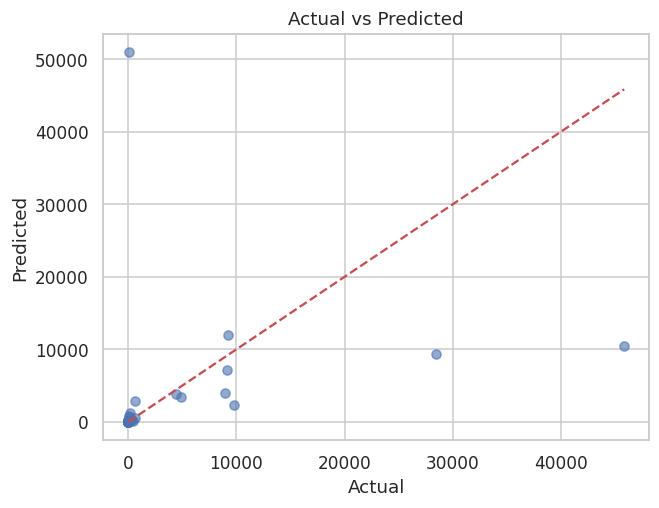


--- FINAL OUTPUT ---
Cleaned CSV saved
Tables displayed cleanly in notebook
Plots generated
Statistical tests handled safely
Regression evaluated properly


In [5]:
# ----------------------------------------------------
# COVID-19 Dataset Analysis 
# ----------------------------------------------------

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from IPython.display import display
import warnings

warnings.filterwarnings("ignore")  # suppress warnings

sns.set(style="whitegrid")
plt.rcParams['figure.dpi'] = 110

# ----------------------------------------------------
# CONFIG
# ----------------------------------------------------
DATA_PATH = "data/Set 4-countrywise_corona.csv"
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)

# ----------------------------------------------------
# HELPER FUNCTIONS
# ----------------------------------------------------
def safe_series(s):
    return s.replace([np.inf, -np.inf], np.nan).dropna()

def detect_column(columns, keywords):
    for c in columns:
        name = c.lower()
        if all(k in name for k in keywords):
            return c
    return None

def iqr_outliers(s):
    s = safe_series(s)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return s[(s < lower) | (s > upper)], lower, upper

# ----------------------------------------------------
# LOAD DATA
# ----------------------------------------------------
df = pd.read_csv(DATA_PATH)
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Dataset Shape:", df.shape)
display(df.head())

# ----------------------------------------------------
# DETECT COLUMNS
# ----------------------------------------------------
cols = df.columns

region_col = detect_column(cols, ["region"])
country_col = detect_column(cols, ["country"])
confirmed_col = detect_column(cols, ["confirm"])
deaths_col = detect_column(cols, ["death"])
last_week_col = detect_column(cols, ["last", "week"])

print("\nDetected Columns:")
print(region_col, country_col, confirmed_col, deaths_col, last_week_col)

# ----------------------------------------------------
# MISSING VALUES TABLE
# ----------------------------------------------------
missing = df.isnull().sum().reset_index()
missing.columns = ["Column", "Missing Values"]
missing = missing.sort_values(by="Missing Values", ascending=False)

print("\nMissing Values:")
display(missing)

# ----------------------------------------------------
# CLEANING
# ----------------------------------------------------
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=np.number).columns

if region_col:
    for c in num_cols:
        df[c] = df.groupby(region_col)[c].transform(lambda x: x.fillna(x.median()))
        df[c] = df[c].fillna(df[c].median())
else:
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.to_csv(os.path.join(OUT_DIR, "cleaned_corona.csv"), index=False)
print("\nCleaned data saved")

# ----------------------------------------------------
# UNIT 1 - SUMMARY STATS
# ----------------------------------------------------
print("\n--- UNIT 1 ---")

summary = df.groupby(region_col)[[confirmed_col, deaths_col]].agg(
    ['mean', 'median', 'std', 'min', 'max']
)

summary.columns = ['_'.join(col) for col in summary.columns]
summary = summary.reset_index().round(2)

print("\nSummary Statistics by Region:")
display(summary)

# ----------------------------------------------------
# VISUALIZATION
# ----------------------------------------------------
def plot_dist(col):
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Distribution")
    
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")
    
    plt.show()

plot_dist(confirmed_col)
plot_dist(deaths_col)

# ----------------------------------------------------
# DISTRIBUTION + OUTLIERS (SAFE)
# ----------------------------------------------------
for col in [confirmed_col, deaths_col]:
    s = safe_series(df[col])
    
    if len(s) > 1:
        skew = stats.skew(s)
    else:
        skew = np.nan
    
    if np.isnan(skew):
        dist = "Insufficient data"
    elif abs(skew) < 0.5:
        dist = "Normal"
    elif skew > 0:
        dist = "Right-skewed"
    else:
        dist = "Left-skewed"
    
    print(f"{col}: {dist} (skew={skew:.2f})")
    
    out, low, up = iqr_outliers(s)
    print(f"Outliers in {col}: {len(out)} (Bounds: {low:.2f}, {up:.2f})")

# Q-Q Plot
if len(df[deaths_col].dropna()) > 1:
    stats.probplot(df[deaths_col].dropna(), dist="norm", plot=plt)
    plt.title("Q-Q Plot (Deaths)")
    plt.show()

# ----------------------------------------------------
# CORRELATION
# ----------------------------------------------------
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

corr_deaths = corr[deaths_col].abs().sort_values(ascending=False).reset_index()
corr_deaths.columns = ["Feature", "Correlation"]
corr_deaths = corr_deaths.round(3)

print("\nTop Correlations with Deaths:")
display(corr_deaths.head(8))

# ----------------------------------------------------
# UNIT 2 - SAFE T-TEST
# ----------------------------------------------------
print("\n--- UNIT 2 ---")

regions = df[region_col].value_counts().index[:2]
r1, r2 = regions

s1 = safe_series(df[df[region_col]==r1][deaths_col])
s2 = safe_series(df[df[region_col]==r2][deaths_col])

if len(s1) > 1 and len(s2) > 1 and s1.std() > 0 and s2.std() > 0:
    t, p = stats.ttest_ind(s1, s2, equal_var=False)
else:
    t, p = np.nan, np.nan
    print("T-test skipped due to low variance or insufficient data")

ttable = pd.DataFrame({
    "Region": [r1, r2],
    "Mean Deaths": [s1.mean(), s2.mean()],
    "Sample Size": [len(s1), len(s2)]
}).round(2)

print("\nT-Test Comparison:")
display(ttable)

print(f"T-statistic = {t}, p-value = {p}")

# Margin of Error (SAFE)
all_d = safe_series(df[deaths_col])
if len(all_d) > 1:
    moe = stats.t.ppf(0.975, len(all_d)-1) * stats.sem(all_d)
    print(f"Margin of Error: ±{moe:.2f}")
else:
    print("Margin of Error: insufficient data")

# ----------------------------------------------------
# UNIT 3 - SAFE HYPOTHESIS + REGRESSION
# ----------------------------------------------------
print("\n--- UNIT 3 ---")

top_country = df[country_col].value_counts().idxmax()
sample = safe_series(df[df[country_col]==top_country][confirmed_col])

if len(sample) > 1 and sample.std() > 0:
    t, p = stats.ttest_1samp(sample, 10000)
    print(f"{top_country} test: t={t:.3f}, p={p:.5f}")
else:
    print("One-sample test skipped (low variance or small sample)")

# Regression
reg_df = df[[confirmed_col, deaths_col, region_col]].dropna()

X = pd.get_dummies(reg_df[[confirmed_col, region_col]], drop_first=True)
y = reg_df[deaths_col]

if len(X) > 10:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)
    
    metrics_df = pd.DataFrame({
        "Metric": ["MSE", "RMSE", "R²"],
        "Value": [mse, rmse, r2]
    }).round(3)

    print("\nRegression Metrics:")
    display(metrics_df)

    plt.scatter(y_test, pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title("Actual vs Predicted")
    plt.show()
else:
    print("Not enough data for regression")

# ----------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------
print("\n--- FINAL OUTPUT ---")
print("Cleaned CSV saved")
print("Tables displayed cleanly in notebook")
print("Plots generated")
print("Statistical tests handled safely")
print("Regression evaluated properly")
